In [18]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
import glob
import photutils
from photutils import aperture as apt
from astropy.table import QTable
import os 
print(os.getcwd)
os.makedirs("reduced_sci", exist_ok=True)

<built-in function getcwd>


# Flat Field and Bias Subtraction
### Plots for combined, normalized flat image

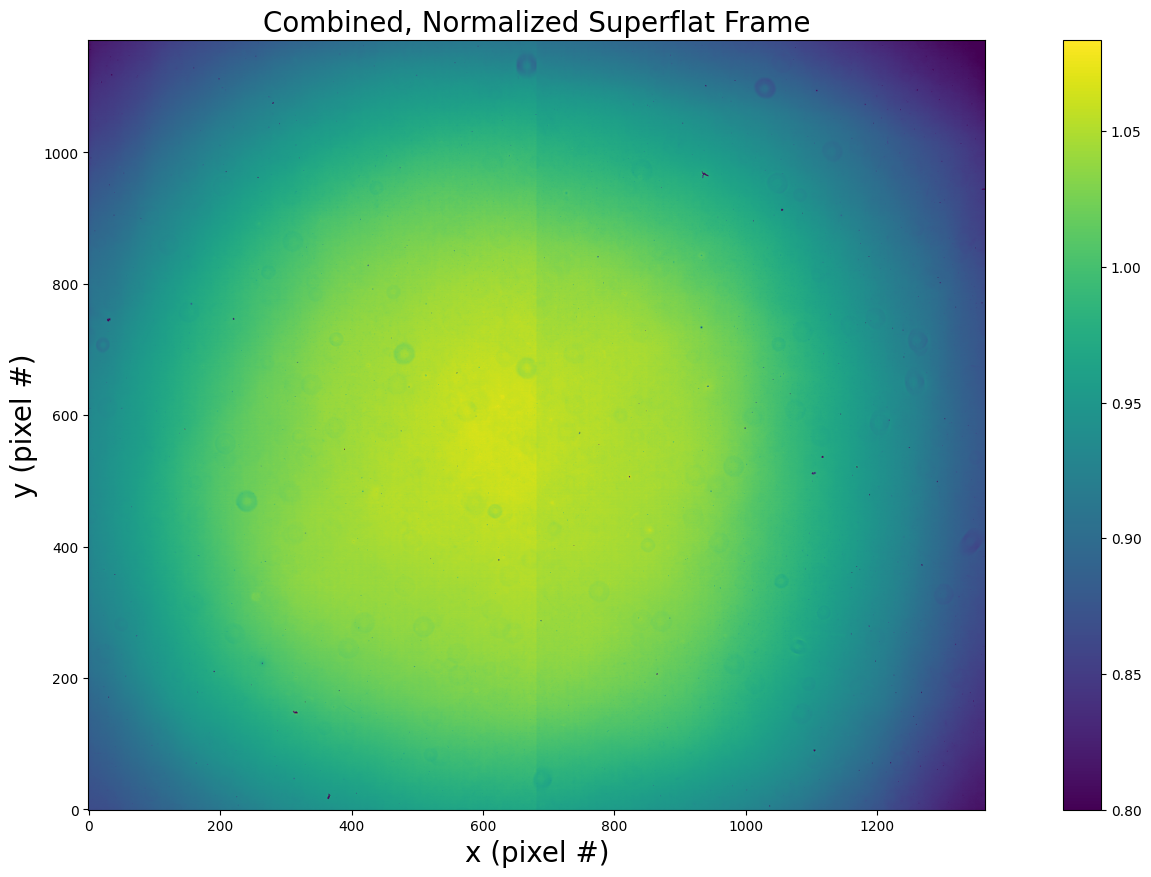

In [6]:
# Access the superflat file
superflat_normalized = fits.getdata("sflat.fits")

plt.figure("Superflat", figsize=(20, 10))
plt.title("Combined, Normalized Superflat Frame", size = 20)
plt.imshow(superflat_normalized, origin = 'lower', vmin=0.8)#, vmin = 560, vmax = 565)
plt.colorbar()
plt.xlabel('x (pixel #)', size = 20)
plt.ylabel('y (pixel #)', size = 20)
plt.show()

### Plot for combined bias image

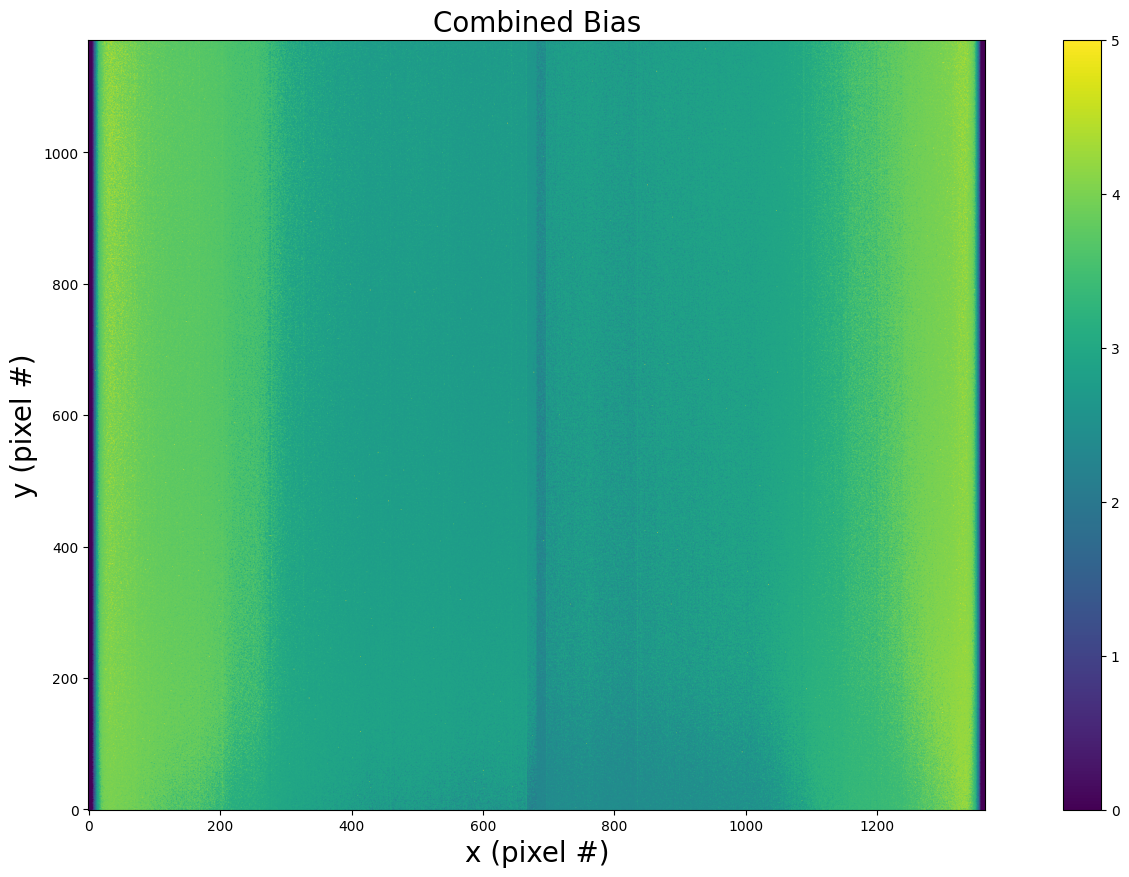

In [8]:
# Access the bias file
superbias = fits.getdata("bias.fits")

plt.figure("Bias", figsize=(20, 10))
plt.title("Combined Bias", size = 20)
plt.imshow(superbias, origin = 'lower',vmin=0, vmax=5)#, vmin = 560, vmax = 565)
plt.colorbar()
plt.xlabel('x (pixel #)', size = 20)
plt.ylabel('y (pixel #)', size = 20)
plt.show()

### Call in all raw science images, apply image correction to all raw science images, and write to a new set of reduced images

In [20]:
files = glob.glob('2m0753.*.fits')
files = np.array(files)

file_nos = np.zeros(len(files))

for i, filename in enumerate(files):
    file_nos[i] = float(filename.split('.')[1])

order = np.argsort(file_nos)
files = files[order]

print(glob.glob('sci_images/*')[:5])
print(len(glob.glob('sci_images/*')))

for f in files:
    print(f)

    # open the fits file and read the data
    image = fits.open(f)
    raw_sci = image[0].data
    header = image[0].header

    # apply the bias and superflat corrections
    reduced_sci = (raw_sci - superbias) / superflat_normalized

    # subtract sky background
    skyloc1 = reduced_sci[260:360, 632:732]
    skyloc2 = reduced_sci[610:710, 75:175]
    skyloc3 = reduced_sci[735:835, 1000:1100]

    skymed1 = np.median(skyloc1)
    skymed2 = np.median(skyloc2)
    skymed3 = np.median(skyloc3)

    sky_background = np.median([skymed1, skymed2, skymed3])
    reduced_sci = reduced_sci - sky_background

    # save the reduced image to a new fits file
    reduced_image = fits.PrimaryHDU(data=reduced_sci, header=header)
    reduced_image.writeto(os.path.join("reduced_sci", "reduced_" + os.path.basename(f)), overwrite=True)

    # close the image
    image.close()

[]
0
2m0753.0001.fits
2m0753.0002.fits
2m0753.0003.fits
2m0753.0004.fits
2m0753.0005.fits
2m0753.0006.fits
2m0753.0007.fits
2m0753.0008.fits
2m0753.0009.fits
2m0753.0010.fits
2m0753.0011.fits
2m0753.0012.fits
2m0753.0013.fits
2m0753.0014.fits
2m0753.0015.fits
2m0753.0016.fits
2m0753.0017.fits
2m0753.0018.fits
2m0753.0019.fits
2m0753.0020.fits
2m0753.0021.fits
2m0753.0022.fits
2m0753.0023.fits
2m0753.0024.fits
2m0753.0025.fits
2m0753.0026.fits
2m0753.0027.fits
2m0753.0028.fits
2m0753.0029.fits
2m0753.0030.fits
2m0753.0031.fits
2m0753.0032.fits
2m0753.0033.fits
2m0753.0034.fits
2m0753.0035.fits
2m0753.0036.fits
2m0753.0037.fits
2m0753.0038.fits
2m0753.0039.fits
2m0753.0040.fits
2m0753.0041.fits
2m0753.0042.fits
2m0753.0043.fits
2m0753.0044.fits
2m0753.0045.fits
2m0753.0046.fits
2m0753.0047.fits
2m0753.0048.fits
2m0753.0049.fits
2m0753.0050.fits
2m0753.0051.fits
2m0753.0052.fits
2m0753.0053.fits
2m0753.0054.fits
2m0753.0055.fits
2m0753.0056.fits
2m0753.0057.fits
2m0753.0058.fits
2m0753.00

### Plot for raw science image 

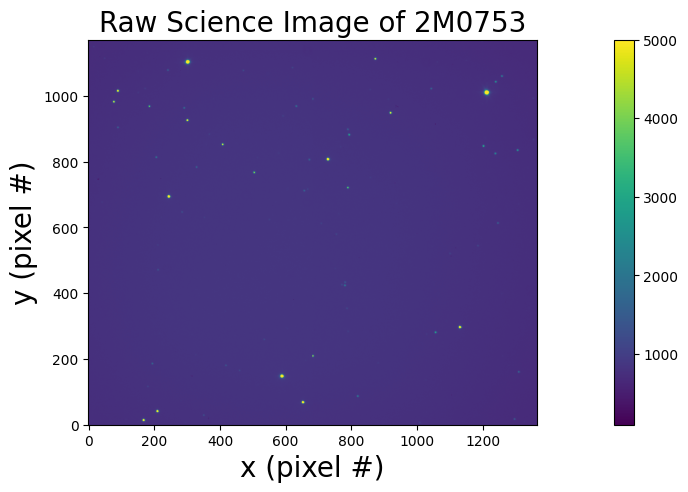

In [21]:
raw_science_image = fits.getdata("2m0753.0001.fits")

plt.figure('Raw Science Image of 2M0753', figsize = (20, 5))
plt.title('Raw Science Image of 2M0753', size = 20)
plt.imshow(raw_science_image, origin = 'lower',vmin=100, vmax=5000)
plt.colorbar()
plt.xlabel('x (pixel #)', size = 20)
plt.ylabel('y (pixel #)', size = 20)
plt.xlim()
plt.ylim()
plt.show()

### Single reduced image 

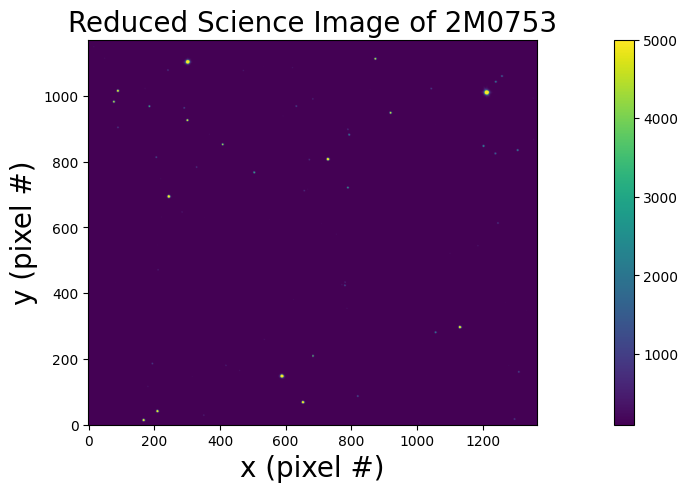

In [23]:
sci_reduced_image = fits.getdata("reduced_sci/reduced_2m0753.0001.fits")

plt.figure('Reduced Science Image of 2M0753', figsize = (20, 5))
plt.title('Reduced Science Image of 2M0753', size = 20)
plt.imshow(sci_reduced_image, origin = 'lower',vmin=100, vmax=5000)
plt.colorbar()
plt.xlabel('x (pixel #)', size = 20)
plt.ylabel('y (pixel #)', size = 20)
plt.xlim()
plt.ylim()
plt.show()

# Aperture Photometry
### Zoom in on target

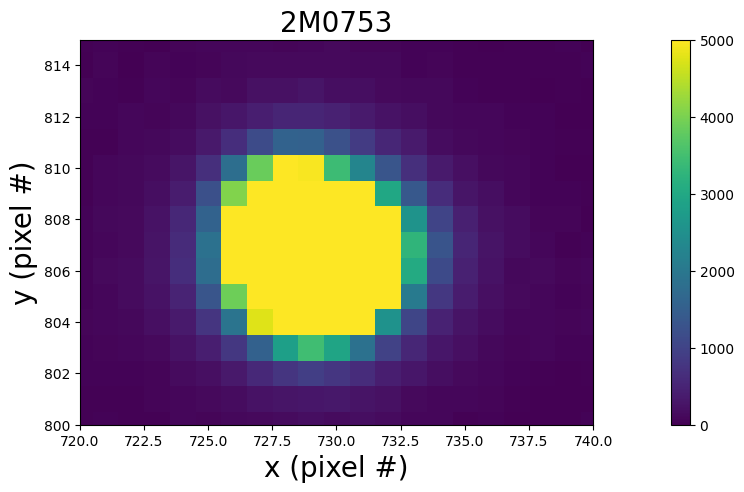

In [24]:
plt.figure('Mont4K CCD - WISE 0855', figsize = (20, 5))
plt.title('2M0753', size = 20)
plt.imshow(sci_reduced_image, vmin=0, vmax = 5000, origin = 'lower')
plt.colorbar()
plt.xlabel('x (pixel #)', size = 20)
plt.ylabel('y (pixel #)', size = 20)
plt.xlim(720,740)
plt.ylim(800,815)
plt.show()

### Average FWHM for target and reference stars, get extraction radius for target 

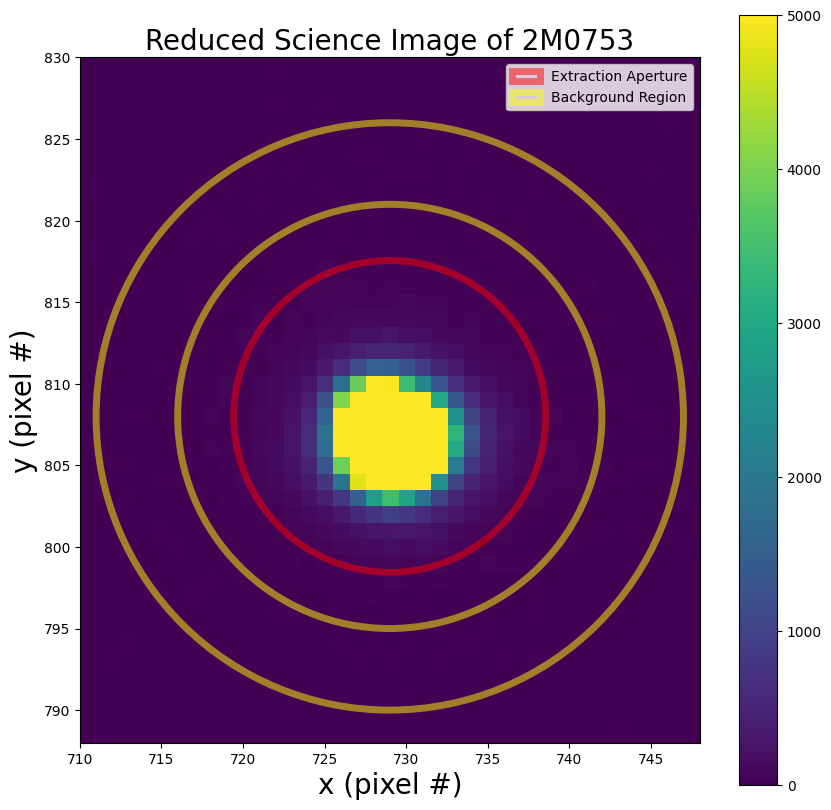

In [28]:
info_file = "2m0753.stats"
fwhm_values = []

with open(info_file, 'r') as f:
    for line in f:
        # Turn each line into a list of value
        line = line.strip("\n").split(" ")
        
        # Skip the headers
        if "2m0753" not in line[0]:
            continue
        
        # Extract the FWHM value and append it to the list
        fwhm_values.append(float(line[-2]))
f.close()

target_center_pixel_x = 729  #center of target location (x) in pixels
target_center_pixel_y = 808  #center of target location (y) in pixels
target_aperture_radius = 2.25*fwhm_values[0]   # radial width of extraction in pixels (suggested by Dr. Green)
r_in = 13             # inner radius of background annulus in pixels (suggested by Dr. Green)
r_out = 18            # outer radius of background annulus in pixels (suggested by Dr. Green)
target_aperture = apt.CircularAperture((target_center_pixel_x, target_center_pixel_y), r=target_aperture_radius) 
target_annulus = apt.CircularAnnulus((target_center_pixel_x, target_center_pixel_y), r_in, r_out)

plt.figure('Mont4K CCD Image of 2M0753', figsize = (10, 10))
plt.title('Reduced Science Image of 2M0753', size = 20)
plt.imshow(sci_reduced_image, vmin = 0, vmax = 5000, origin = 'lower')
target_aperture.plot(color='red', lw=5, alpha=0.5, label = 'Extraction Aperture')
target_annulus.plot(color='yellow', lw=5, alpha=0.5, label = 'Background Region')
plt.colorbar()
plt.xlabel('x (pixel #)', size = 20)
plt.ylabel('y (pixel #)', size = 20)
plt.xlim([710,748])
plt.ylim([788,830])
plt.legend()
plt.show()

### Repeat for all reduced science images

In [57]:
reduced_files = glob.glob('reduced_sci/*')
reduced_files = np.array(reduced_files)

file_nos = np.zeros(len(reduced_files))

for i, filename in enumerate(reduced_files):
    file_nos[i] = float(filename.split('.')[1])
    
order = np.argsort(file_nos)
reduced_files = reduced_files[order]

# Empty arrays to hold the flux & flux error values for each image and time values, respectively
target_extracted_flux_values = []
target_extracted_flux_errors = []
time_stamps = []

index = 0 # Counter for the fwhm values, which are in the same order as the reduced images 
            # and will be used to set the aperture sizes for photometry
            
for f in reduced_files:
    # Read in the individual reduced science image from the file
    individual_reduced_sci_image = fits.getdata(f) 
    
    # Extract the HJD from header and add to time array (for plotting light curve)
    header = fits.getheader(f)
    hjd = header['HJD'] - 2461104 ## Convert to time since first observation
    time_stamps = np.append(time_stamps, hjd)
    
    # Apply aperture extraction
    target_center_pixel_x = 729  #center of target location (x) in pixels
    target_center_pixel_y = 808  #center of target location (y) in pixels
    target_aperture_radius = 2.25*fwhm_values[index]   # Optimal radial width of extraction in pixels (suggested by Dr. Green)
    r_in = 13             # inner radius of background annulus in pixels (suggested by Dr. Green)
    r_out = 18            # outer radius of background annulus in pixels (suggested by Dr. Green)
    target_aperture = apt.CircularAperture((target_center_pixel_x, target_center_pixel_y), r=target_aperture_radius) # Aperture
    target_annulus = apt.CircularAnnulus((target_center_pixel_x, target_center_pixel_y), r_in, r_out) # Annulus
    target_phot_table = photutils.aperture.aperture_photometry(individual_reduced_sci_image, target_aperture)
    
    # Extract the flux value and append to the flux array
    target_flux = target_phot_table['aperture_sum'][0]
    target_extracted_flux_values = np.append(target_extracted_flux_values, target_flux)
    
    # Calculate the flux error and append to the flux error array
    bkg_stats = photutils.aperture.ApertureStats(individual_reduced_sci_image, target_annulus)
    bkg_sigma = bkg_stats.std
    target_flux_err = np.sqrt(target_aperture.area)*bkg_sigma
    target_extracted_flux_errors = np.append(target_extracted_flux_errors, target_flux_err)
    
    # Increase the index counter to set the average FWHM for the next image
    index += 1

# Convert the time, flux, and flux error arrays to numpy arrays for plotting
time_stamps = np.array(time_stamps)
target_extracted_flux_values = np.array(target_extracted_flux_values)
target_extracted_flux_errors = np.array(target_extracted_flux_errors)

### Targets Flux over time with error

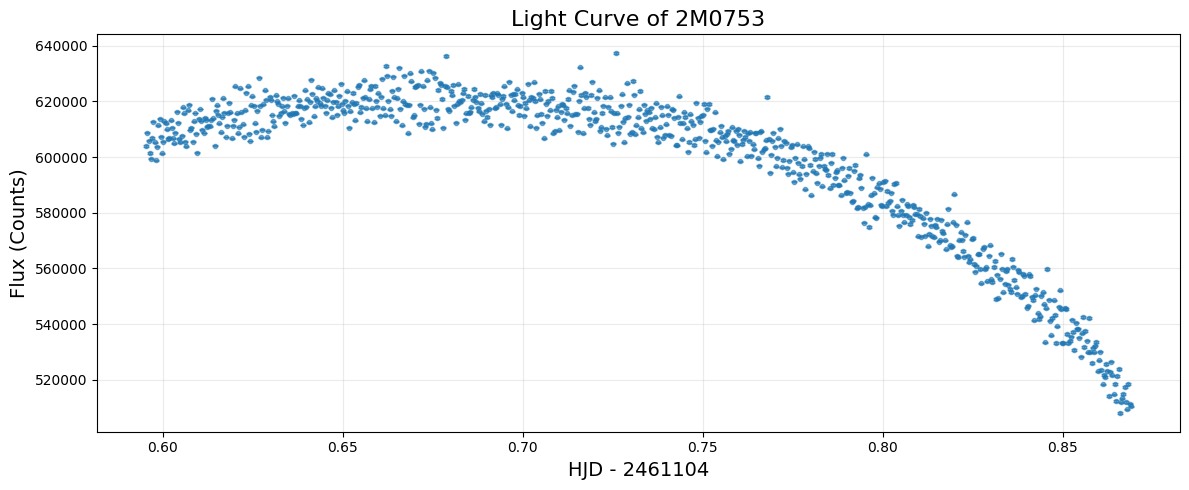

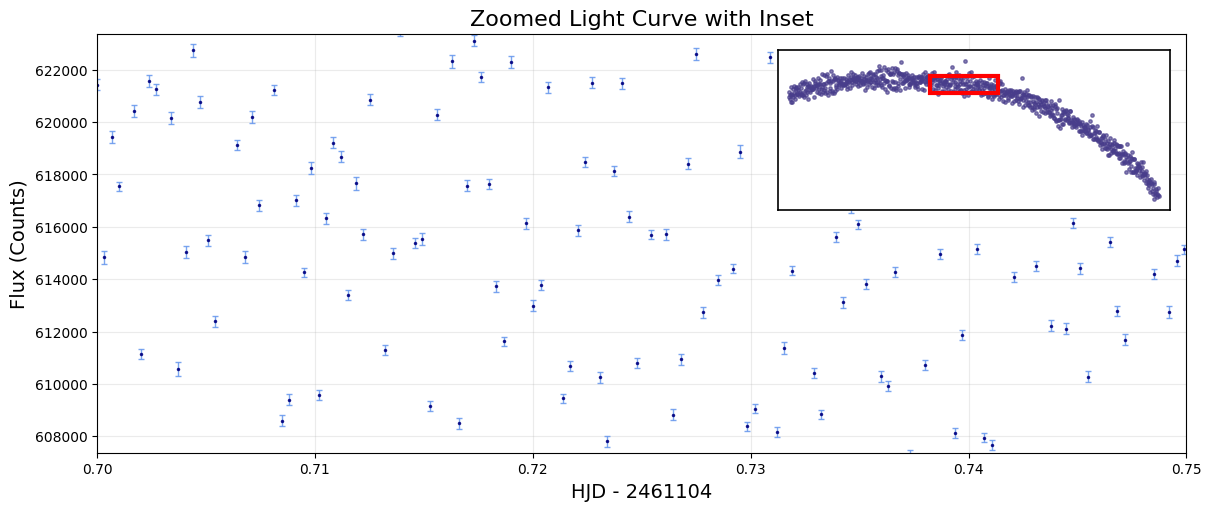

In [58]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.patches import Rectangle
# PLOT 1: Regular flux over time
plt.figure(figsize=(12, 5))

plt.errorbar(
    time_stamps,
    target_extracted_flux_values,
    yerr=target_extracted_flux_errors,
    fmt='o',
    markersize=3,
    elinewidth=0.8,
    capsize=2,
    alpha=0.6
)

plt.title("Light Curve of 2M0753", fontsize=16)
plt.xlabel("HJD - 2461104", fontsize=14)
plt.ylabel("Flux (Counts)", fontsize=14)

plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()
# error bars are basically invisible to the scale. ~600,000 counts and errors average 204
# min is 134 and max is 340, I wanna find a way to make them more visible

# PLOT 2: Zoomed plot with inset plot 
# zoomed in so error bars are actually visible
xmin, xmax = 0.70, 0.75
mask = (time_stamps >= xmin) & (time_stamps <= xmax)
local_flux = target_extracted_flux_values[mask]

zoom_ymin = np.mean(local_flux) - 8000
zoom_ymax = np.mean(local_flux) + 8000

fig, ax = plt.subplots(figsize=(12, 5), constrained_layout=True)

# main zoomed plot
ax.errorbar(
    time_stamps,
    target_extracted_flux_values,
    yerr=target_extracted_flux_errors,
    fmt='.',
    markersize=3,
    elinewidth=1,
    capsize=2,
    color='navy',
    ecolor='cornflowerblue',
    alpha=0.85
)

ax.set_title("Zoomed Light Curve with Inset", fontsize=16)
ax.set_xlabel("HJD - 2461104", fontsize=14)
ax.set_ylabel("Flux (Counts)", fontsize=14)

ax.set_xlim(xmin, xmax)
ax.set_ylim(zoom_ymin, zoom_ymax)
ax.grid(alpha=0.25)

# inset plot showing full light curve
axins = inset_axes(ax, width="36%", height="38%", loc="upper right", borderpad=1.2)

axins.scatter(
    time_stamps,
    target_extracted_flux_values,
    s=6,
    color='darkslateblue',
    alpha=0.65
)

# add padding so full curve is not cramped
xpad = 0.03 * (np.max(time_stamps) - np.min(time_stamps))
ypad = 0.08 * (np.max(target_extracted_flux_values) - np.min(target_extracted_flux_values))

axins.set_xlim(np.min(time_stamps) - xpad, np.max(time_stamps) + xpad)
axins.set_ylim(np.min(target_extracted_flux_values) - ypad,
               np.max(target_extracted_flux_values) + ypad)

# bold zoom box
box = Rectangle(
    (xmin, zoom_ymin),
    xmax - xmin,
    zoom_ymax - zoom_ymin,
    fill=False,
    edgecolor='red',
    linewidth=3
)

axins.add_patch(box)
axins.set_xticks([])
axins.set_yticks([])

# adjusting visual
for spine in axins.spines.values():
    spine.set_edgecolor("black")
    spine.set_linewidth(1.2)

plt.show()

# maybe try plotting fewer points to reduce clutter as another plot option later

### Normalizing Flux of target with reference stars

Important to see if the target's variability deviates from the environmental effects.

In [69]:
# locations of reference stars as (x, y)
ref_locations = np.array([
    [653.16, 70.03],
    [1130.54, 298.10],
    [245.35, 694.94],
    [789.93, 721.77],
    [1306.31, 835.58],
    [1202.37, 848.19],
    [409.20, 853.11],
    [301.97, 926.50],
    [919.89, 949.05],
    [90.50, 1015.82],
    [873.49, 1113.11]
])

# lists to store fluxes/errors for every reference star
allref_flux_values = []
allref_flux_errors = []

# background annulus radii
r_in = 13
r_out = 18

# loop through each reference star
for x_ref, y_ref in ref_locations:

    ref_fluxes = []
    ref_errors = []

    # loop through each reduced science image
    for i, filename in enumerate(reduced_files):

        # read reduced image
        image_data = fits.getdata(filename)

        # set aperture size using fwhm for this image
        aperture_radius = 2.25 * fwhm_values[i]

        # create aperture and background annulus
        aperture = apt.CircularAperture((x_ref, y_ref), r=aperture_radius)
        annulus = apt.CircularAnnulus((x_ref, y_ref), r_in=r_in, r_out=r_out)

        # measure flux inside aperture
        phot_table = photutils.aperture.aperture_photometry(image_data, aperture)
        flux = phot_table["aperture_sum"][0]

        # estimate background noise from annulus
        bkg_stats = photutils.aperture.ApertureStats(image_data, annulus)
        bkg_sigma = bkg_stats.std

        # calculate flux error
        flux_error = np.sqrt(aperture.area) * bkg_sigma

        # save values for this image
        ref_fluxes.append(flux)
        ref_errors.append(flux_error)

    # save all image measurements for this reference star
    allref_flux_values.append(ref_fluxes)
    allref_flux_errors.append(ref_errors)

# convert to arrays with shape: (number of reference stars, number of images)
allref_flux_values = np.array(allref_flux_values)
allref_flux_errors = np.array(allref_flux_errors)

# SNR
snr = (280 / 550000) * 100
print(f"SNR: {snr:.2f}%")

print("reference flux shape:", allref_flux_values.shape)
print("reference error shape:", allref_flux_errors.shape)
for i in range(3):
    print(f"\nRef Star {i}")
    for j in range(5):
        print(f"  Image {j}: Flux = {allref_flux_values[i][j]:.2f}, Error = {allref_flux_errors[i][j]:.2f}")

SNR: 0.05%
reference flux shape: (11, 806)
reference error shape: (11, 806)

Ref Star 0
  Image 0: Flux = 550409.77, Error = 282.72
  Image 1: Flux = 550284.95, Error = 299.28
  Image 2: Flux = 549934.32, Error = 294.24
  Image 3: Flux = 551576.32, Error = 288.13
  Image 4: Flux = 550724.65, Error = 267.31

Ref Star 1
  Image 0: Flux = 453077.98, Error = 278.56
  Image 1: Flux = 453520.10, Error = 311.45
  Image 2: Flux = 453020.43, Error = 266.01
  Image 3: Flux = 454567.21, Error = 259.83
  Image 4: Flux = 452552.92, Error = 248.69

Ref Star 2
  Image 0: Flux = 805373.84, Error = 303.15
  Image 1: Flux = 805378.59, Error = 324.44
  Image 2: Flux = 804539.15, Error = 286.95
  Image 3: Flux = 807384.62, Error = 316.08
  Image 4: Flux = 803921.52, Error = 280.81


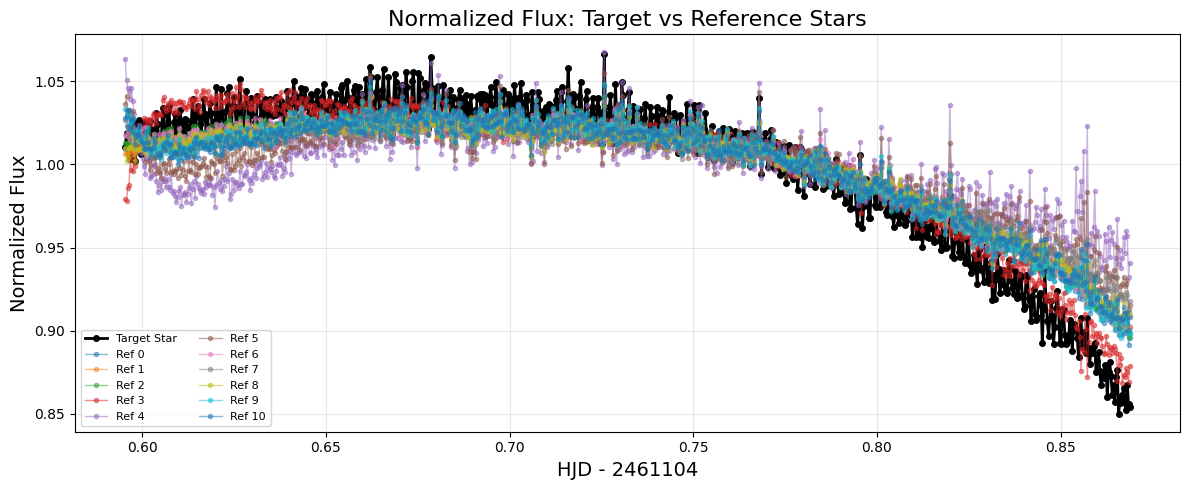

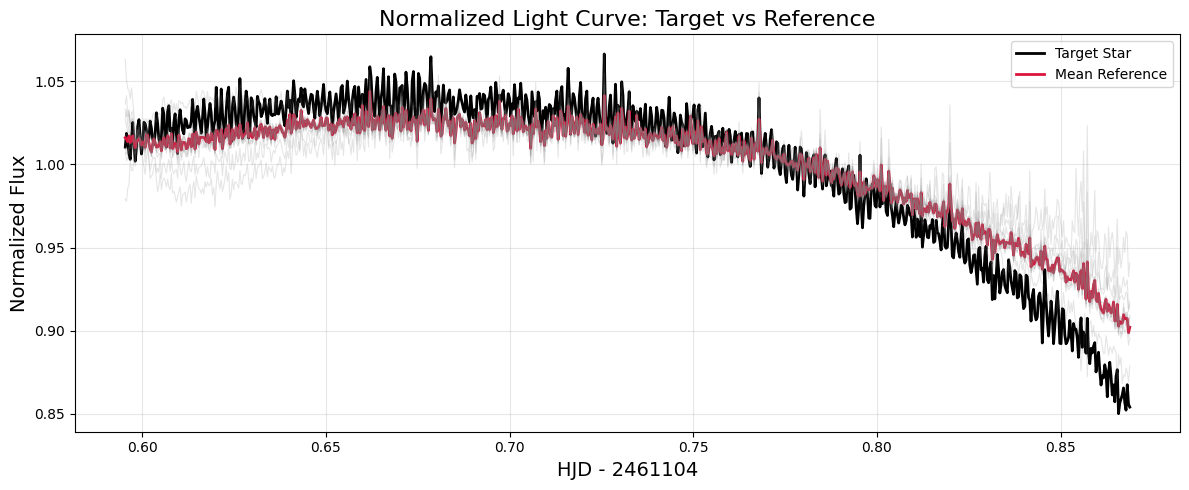

In [89]:
plt.figure(figsize=(12, 5))

target_norm = target_extracted_flux_values / np.mean(target_extracted_flux_values)

plt.plot(
    time_stamps,
    target_norm,
    marker='o',
    markersize=4,
    linewidth=2,
    color='black',
    label="Target Star"
)

# reference stars
for i in range(allref_flux_values.shape[0]):
    ref_norm = allref_flux_values[i] / np.mean(allref_flux_values[i])

    plt.plot(
        time_stamps,
        ref_norm,
        marker='o',
        markersize=3,
        linewidth=1,
        alpha=0.5,
        label=f"Ref {i}"
    )

plt.title("Normalized Flux: Target vs Reference Stars", fontsize=16)
plt.xlabel("HJD - 2461104", fontsize=14)
plt.ylabel("Normalized Flux", fontsize=14)

plt.grid(alpha=0.3)
plt.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

# kinda messy, maybe if I get a mean reference star value and compare to our target star
plt.figure(figsize=(12, 5))

# target
target_norm = target_extracted_flux_values / np.mean(target_extracted_flux_values)

plt.plot(
    time_stamps,
    target_norm,
    color='black',
    linewidth=2,
    label='Target Star'
)

# mean reference for comparison
ref_mean = np.mean(allref_flux_values, axis=0)
ref_mean_norm = ref_mean / np.mean(ref_mean)

plt.plot(
    time_stamps,
    ref_mean_norm,
    color='crimson',
    linewidth=2,
    label='Mean Reference'
)

# reference stars individual plots with it very faintly in the background
for i in range(allref_flux_values.shape[0]):
    ref_norm = allref_flux_values[i] / np.mean(allref_flux_values[i])

    plt.plot(
        time_stamps,
        ref_norm,
        color='gray',
        alpha=0.2,
        linewidth=0.8
    )

plt.title("Normalized Light Curve: Target vs Reference", fontsize=16)
plt.xlabel("HJD - 2461104", fontsize=14)
plt.ylabel("Normalized Flux", fontsize=14)

plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

### New error bar plots with normalized data

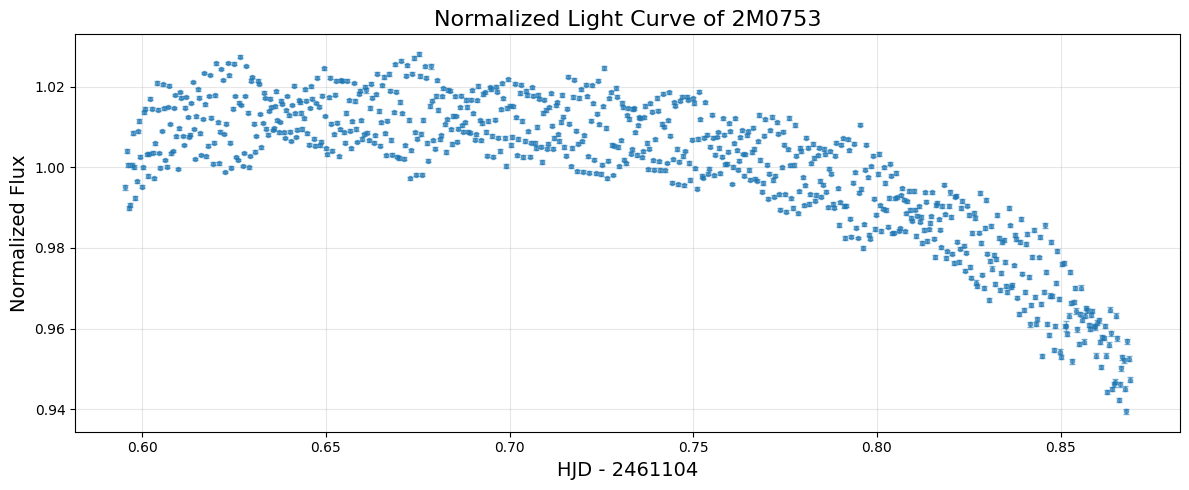

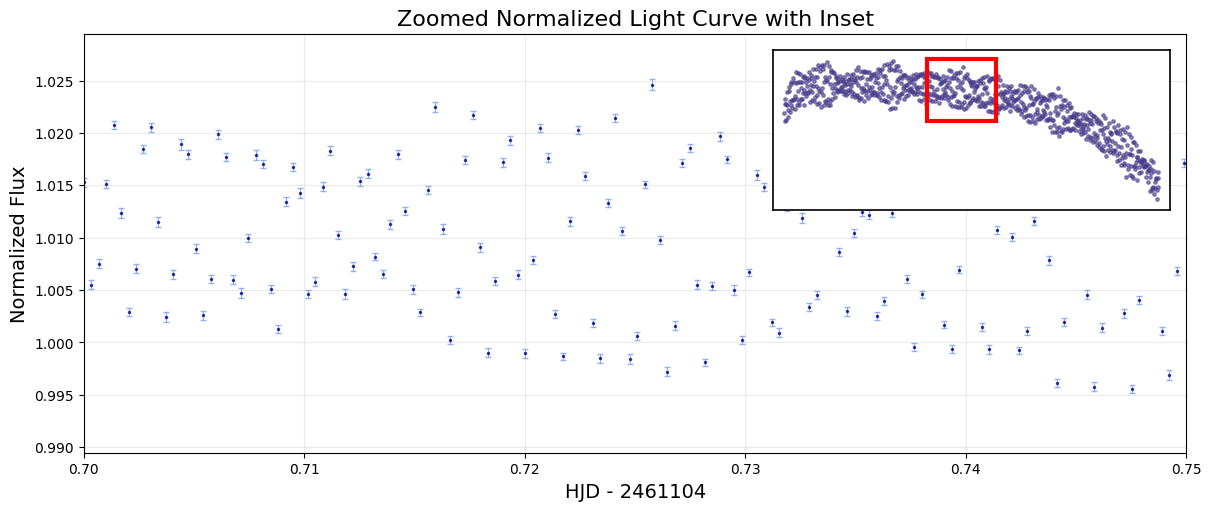

In [88]:
# PLOT 1: Normalized flux over time with error bars plot
# mean reference flux (comparison)
ref_mean = np.mean(allref_flux_values, axis=0)

# normalized flux
normalized_flux = target_extracted_flux_values / ref_mean
normalized_flux /= np.mean(normalized_flux)

# error propagation
N_ref = allref_flux_values.shape[0]
ref_std = np.std(allref_flux_values, axis=0)
ref_err = np.sqrt(np.sum(allref_flux_errors**2, axis=0)) / N_ref

frac_err = np.sqrt(
    (target_extracted_flux_errors / target_extracted_flux_values)**2 +
    (ref_err / ref_mean)**2
)

normalized_errors = normalized_flux * frac_err

# plot
plt.figure(figsize=(12, 5))
plt.errorbar(
    time_stamps,
    normalized_flux,
    yerr=normalized_errors,
    fmt='o',
    markersize=3,
    elinewidth=1,
    capsize=2,
    alpha=0.6
)

plt.title("Normalized Light Curve of 2M0753", fontsize=16)
plt.xlabel("HJD - 2461104", fontsize=14)
plt.ylabel("Normalized Flux", fontsize=14)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# PLOT 2: Zoomed light curve
xmin, xmax = 0.70, 0.75
mask = (time_stamps >= xmin) & (time_stamps <= xmax)
local_flux = normalized_flux[mask]

zoom_ymin = np.mean(local_flux) - 0.02
zoom_ymax = np.mean(local_flux) + 0.02

fig, ax = plt.subplots(figsize=(12, 5), constrained_layout=True)

# main zoomed plot
ax.errorbar(
    time_stamps,
    normalized_flux,
    yerr=normalized_errors,
    fmt='.',
    markersize=3,
    elinewidth=0.8,
    capsize=2,
    color='navy',
    ecolor='cornflowerblue',
    alpha=0.7
)

ax.set_title("Zoomed Normalized Light Curve with Inset", fontsize=16)
ax.set_xlabel("HJD - 2461104", fontsize=14)
ax.set_ylabel("Normalized Flux", fontsize=14)

ax.set_xlim(xmin, xmax)
ax.set_ylim(zoom_ymin, zoom_ymax)
ax.grid(alpha=0.25)

# inset plot showing full light curve
axins = inset_axes(ax, width="36%", height="38%", loc="upper right", borderpad=1.2)

axins.scatter(
    time_stamps,
    normalized_flux,
    s=6,
    color='darkslateblue',
    alpha=0.6
)

# add padding so full curve is not cramped
xpad = 0.03 * (np.max(time_stamps) - np.min(time_stamps))
ypad = 0.08 * (np.max(normalized_flux) - np.min(normalized_flux))

axins.set_xlim(np.min(time_stamps) - xpad, np.max(time_stamps) + xpad)
axins.set_ylim(np.min(normalized_flux) - ypad,
               np.max(normalized_flux) + ypad)

# bold zoom box
box = Rectangle(
    (xmin, zoom_ymin),
    xmax - xmin,
    zoom_ymax - zoom_ymin,
    fill=False,
    edgecolor='red',
    linewidth=3
)

axins.add_patch(box)
axins.set_xticks([])
axins.set_yticks([])

# adjusting visual
for spine in axins.spines.values():
    spine.set_edgecolor("black")
    spine.set_linewidth(1.2)

plt.show()

# Fourier Transform and Lomb-Scargle
### Lomb-Scargle calculation

##### Notes from Astropy article on Lomb-Scargle
- Goal: What repeating frequency is hidden in this brightness data?
- Use Lomb-Scargle for unevenly spaced time data. Output is frequency vs. power -> tall peaks mean the frequency is a good repeating pattern in the data.
- I'm going to use normalized flux, maybe detrend it before so that there isn't fake low-frequency peaks.
- autopower() chooses a frequency grid, helps not miss peaks.
- false_alarm_probability() essentially asks if the data were just noise, how likely would we be to get a peak this strong? If small value, there's stronger evidence the peak is real. Keep in mind this is an approximation. (How likely one specific peak is to be fake)
- 1% false alarm level: if a spike is below that line on the graph, there's a good chance it's just random noise. Cutoff where only 1% of fake/noise signals would be stronger than that. (Estimated line for real vs fake peaks)

In [98]:
from astropy.timeseries import LombScargle

# detrending normalized light curve (plz work)
trend_order = 2
trend_coeffs = np.polyfit(ls_time, ls_flux, trend_order)
trend = np.polyval(trend_coeffs, ls_time)
detrended_flux = ls_flux / trend
detrended_flux = detrended_flux - np.mean(detrended_flux)

# clean arrays before running lomb-scargle
ls_time = np.array(time_stamps)
ls_flux = np.array(normalized_flux)
ls_flux_err = np.array(normalized_errors)

# remove bad values
good = (
    np.isfinite(ls_time) &
    np.isfinite(ls_flux) &
    np.isfinite(ls_flux_err) &
    (ls_flux_err > 0)
)

ls_time = ls_time[good]
ls_flux = ls_flux[good]
ls_flux_err = ls_flux_err[good]

# sort by time
order = np.argsort(ls_time)
ls_time = ls_time[order]
ls_flux = ls_flux[order]
ls_flux_err = ls_flux_err[order]

# compute Nyquist frequency estimate from median time spacing
dt = np.diff(ls_time)
median_dt = np.median(dt)
nyquist_estimate = 0.5 / median_dt
print("Median cadence:", median_dt, "days")
print("Median cadence:", median_dt * 24 * 60 * 60, "seconds")
print("Estimated Nyquist frequency:", nyquist_estimate, "cycles/day")

# remove slow trend from normalized flux
trend_order = 2
trend_coeffs = np.polyfit(ls_time, ls_flux, trend_order)
trend = np.polyval(trend_coeffs, ls_time)

detrended_flux = ls_flux / trend
detrended_flux = detrended_flux - np.mean(detrended_flux)

# set frequency range
min_freq = 100
max_freq = nyquist_estimate
samples_per_peak = 10

# run lomb-scargle
ls = LombScargle(ls_time, detrended_flux, ls_flux_err)

frequency, power = ls.autopower(
    minimum_frequency=min_freq,
    maximum_frequency=max_freq,
    samples_per_peak=samples_per_peak
)

# find strongest peak below nyquist
best_index = np.argmax(power)
best_frequency = frequency[best_index]
best_power = power[best_index]

best_period_days = 1 / best_frequency
best_period_seconds = best_period_days * 24 * 60 * 60

print("Best frequency:", best_frequency, "cycles/day")
print("Best period:", best_period_days, "days")
print("Best period:", best_period_seconds, "seconds")
print("Best power:", best_power)

# first run i got 1.0 cycles/day best frequency and 1.0 days best period which is not
# our pulsation, this is our min_freq though. this makes me think there's a slow trend
# in my light curve so it's probably atmosphere/airmass stuff, or maybe my normalization
# is off. Also false alarm probability being 0 is raising red flags. This tells me that
# the low-freq trend is real not that the pulsation is there. I'm gonna try detrending
# the normalized light curve and see what happens.

# okay that looks better to me i think. i got an estimated nyquist as 1470 per day but
# it goes to 10000 per day so the peaks past 1470 are above the usable limit, too fast
# to trust. gonna cut the ones above that out and see what happens.

# 

Median cadence: 0.0003400803543627262 days
Median cadence: 29.382942616939545 seconds
Estimated Nyquist frequency: 1470.2407639422333 cycles/day
Best frequency: 616.0457495425937 cycles/day
Best period: 0.0016232560661971736 days
Best period: 140.2493241194358 seconds
Best power: 0.7484193416270264


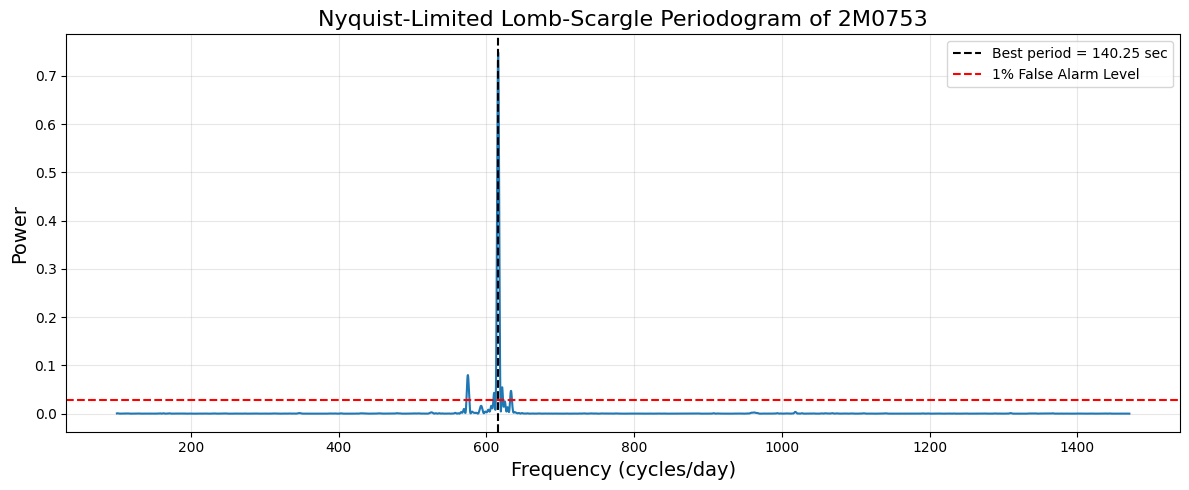

In [103]:
# lomb-scargle periodogram
plt.figure(figsize=(12, 5))
plt.plot(frequency, power)

# strongest frequency marker
plt.axvline(
    best_frequency,
    color="black",
    linestyle="--",
    label=f"Best period = {best_period_seconds:.2f} sec"
)

# false alarm threshold marker
plt.axhline(
    false_alarm_level,
    color="red",
    linestyle="--",
    label="1% False Alarm Level"
)

plt.title("Nyquist-Limited Lomb-Scargle Periodogram of 2M0753", fontsize=16)
plt.xlabel("Frequency (cycles/day)", fontsize=14)
plt.ylabel("Power", fontsize=14)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [99]:
fap = ls.false_alarm_probability(
    best_power,
    minimum_frequency=min_freq,
    maximum_frequency=max_freq,
    method="bootstrap"
)

print("False alarm probability:", fap)

# calculate 1% false alarm level
false_alarm_level = ls.false_alarm_level(
    0.01,
    minimum_frequency=min_freq,
    maximum_frequency=max_freq
)

print("1% false alarm level:", false_alarm_level)

False alarm probability: 0.0
1% false alarm level: 0.029045639243772084


### Sanity check if the ~140 sec peak shows up if data is split into pieces

First Half Lomb-Scargle
Best frequency: 615.7837526553254 cycles/day
Best period: 140.3089958567987 seconds



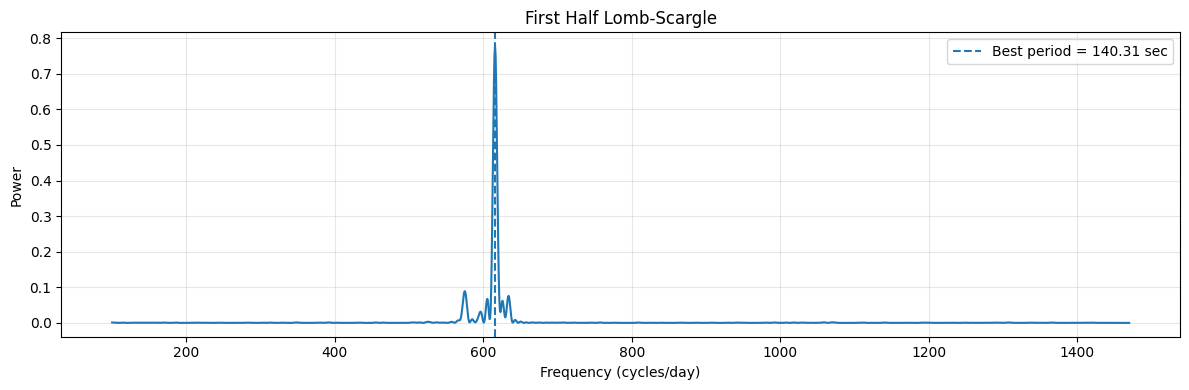

Second Half Lomb-Scargle
Best frequency: 616.1282766168559 cycles/day
Best period: 140.2305384755592 seconds



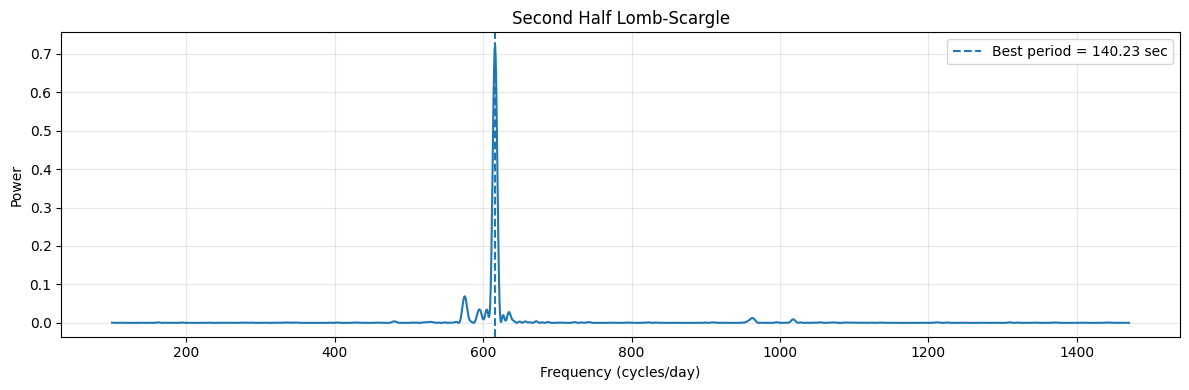

In [101]:
# split data into two halves and check if the same peak appears

mid = len(ls_time) // 2

time_first = ls_time[:mid]
flux_first = detrended_flux[:mid]
err_first = ls_flux_err[:mid]

time_second = ls_time[mid:]
flux_second = detrended_flux[mid:]
err_second = ls_flux_err[mid:]

def run_ls_subset(time_subset, flux_subset, err_subset, label):
    ls_subset = LombScargle(time_subset, flux_subset, err_subset)

    frequency_subset, power_subset = ls_subset.autopower(
        minimum_frequency=min_freq,
        maximum_frequency=max_freq,
        samples_per_peak=samples_per_peak
    )

    best_i = np.argmax(power_subset)
    best_f = frequency_subset[best_i]
    best_period_sec = (1 / best_f) * 24 * 60 * 60

    print(label)
    print("Best frequency:", best_f, "cycles/day")
    print("Best period:", best_period_sec, "seconds")
    print()

    plt.figure(figsize=(12, 4))
    plt.plot(frequency_subset, power_subset)
    plt.axvline(best_f, linestyle="--", label=f"Best period = {best_period_sec:.2f} sec")
    plt.title(label)
    plt.xlabel("Frequency (cycles/day)")
    plt.ylabel("Power")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

run_ls_subset(time_first, flux_first, err_first, "First Half Lomb-Scargle")
run_ls_subset(time_second, flux_second, err_second, "Second Half Lomb-Scargle")